# Deep Learning Fundamentals: Convolutional Neural Networks (CNNs) for Image Classification

In the previous sessions you built simple and deep neural networks using fully-connected layers. But there's a problem: **fully-connected networks don't scale well to images!**

Consider a 32×32 RGB image:
- Flattened input: 32 × 32 × 3 = 3,072 features
- With just 100 hidden neurons: 3,072 × 100 = 307,200 parameters in the first layer alone!
- For 224×224 images (ImageNet): 224 × 224 × 3 = 150,528 features → millions of parameters!

**Convolutional Neural Networks (CNNs)** solve this problem by:
- Using *local receptive fields* (small filters that scan the image)
- *Sharing weights* across spatial locations (drastically fewer parameters)
- Building *hierarchical features* (edges → textures → parts → objects)

In this notebook, we'll:
1. Explore how convolution works with toy examples
2. Understand padding, stride, and pooling
3. Build and train a CNN on CIFAR-10 (a dataset of 10 classes of small images)
4. Visualize what the CNN learned

In [1]:
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

# Setup data directory
project_root = Path("..").resolve()
data_dir = project_root / "data"

# Detect best available device
device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)

print(f"✓ Imports ready")
print(f"✓ Using device: {device}")
print(f"✓ Data directory: {data_dir}")

✓ Imports ready
✓ Using device: mps
✓ Data directory: /Users/jolan.heyse/Library/CloudStorage/OneDrive-VIB/Documents/Course Material/2026/machine-learning-and-deep-learning-fundamentals/data


## Part 1: Understanding Convolution (The Foundation of CNNs)

Before building a full CNN, let's understand the core operation: convolution. 

A **convolution** slides a small filter (kernel) over an image, computing dot products at each position. Different kernels detect different features:
- **Edge detectors**: Find boundaries between regions
- **Sharpening filters**: Enhance edges and details
- **Blur filters**: Remove noise and smooth the image

Let's see this in action on a tiny toy image!

## 1.1 Convolution on a Toy Image

We start with a tiny 12×12 synthetic image with a bright square in the center. This lets you **directly see** how different kernels transform the image.

<div class="alert alert-block alert-info">
<b>QUESTIONS (before running)</b>

- What do you expect an edge detector to highlight?
- Where will the sharpening kernel have the strongest response?
- Why is the output size smaller than the input (10×10 instead of 12×12)?
- What is the sum of the pixel values for each kernel? Why?
- **Implement a vertical edge kernel** and see how it responds to the same image. What do you observe?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- The edge detector will highlight the boundaries of the bright square, showing a strong response where the intensity changes sharply.
- Same as with the edge detector, the sharpening kernel will have the strongest response at the edges of the bright square, enhancing those features.
- The output size is smaller because the kernel cannot be applied to the borders of the image without going out of bounds.
- The blur kernel has a sum of 1, which means it will conserve the overall brightness while smoothing the image. The sum of the pixel values for the edge and sharpening kernels is zero, which means that in constant regions they map to zero. This way these filters remove brightness information, and highlight changes instead.
- The vertical edge kernel will respond strongly to vertical edges in the image.
</div>

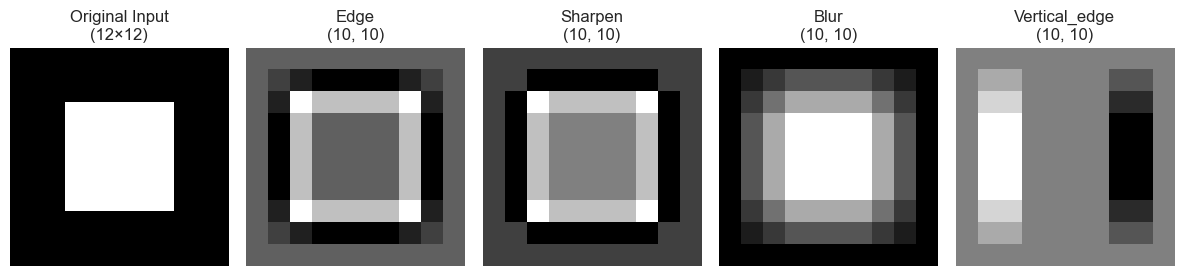

In [10]:
# Create a simple toy image: black background with white square in center
toy = torch.zeros(1, 1, 12, 12)  # Shape: [batch, channels, height, width]
toy[:, :, 3:9, 3:9] = 1.0  # White square from row 3-9, col 3-9

# Define 3x3 kernels for edge detection, sharpening, and blurring
kernels = {
    "edge": torch.tensor([
        [[-1, -1, -1],
         [-1,  8, -1],
         [-1, -1, -1]]
    ], dtype=torch.float32),
    
    "sharpen": torch.tensor([
        [[ 0, -1,  0],
         [-1,  5, -1],
         [ 0, -1,  0]]
    ], dtype=torch.float32),
    
    "blur": torch.tensor([
        [[1, 1, 1],
         [1, 1, 1],
         [1, 1, 1]]
    ], dtype=torch.float32) / 9.0,

    # ADD YOUR VERSION OF A VERTICAL EDGE DETECTOR HERE
    "vertical_edge": torch.tensor([
        [[-1, 0, 1],
         [-1, 0, 1],
         [-1, 0, 1]]
    ], dtype=torch.float32)
}

# Visualize results side-by-side
fig, axes = plt.subplots(1, len(kernels) + 1, figsize=(12, 3))

axes[0].imshow(toy[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original Input\n(12×12)")
axes[0].axis("off")

for ax, (name, k) in zip(axes[1:], kernels.items()):
    out = F.conv2d(toy, k.unsqueeze(0))
    ax.imshow(out[0, 0].detach().numpy(), cmap="gray")
    ax.set_title(f"{name.capitalize()}\n{tuple(out.shape[-2:])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 1.2 Stride and Padding: Controlling Output Size

You noticed the output was 10×10, not 12×12! This happens because:
- A 3×3 kernel cannot be centered on edge pixels (without seeing outside the image)
- **Output size** = (Input size - Kernel size + 1) = 12 - 3 + 1 = 10

We have two tools to control the output size:

**Padding**
- Adds zeros around the image border
- With `padding=1`: 12×12 → 14×14 (after padding) → 12×12 (after conv)
- Preserves spatial dimensions

**Stride**  
- Step size when sliding the kernel
- `stride=1`: slide 1 pixel at a time (default)
- `stride=2`: slide 2 pixels at a time (outputs half the size)
- Used for **downsampling**

Let's see both in action!

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Can we use any arbitrary combination of stride and padding?
- If the kernel is 5×5, how much padding do we need to preserve the input size?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- Not all combinations of stride and padding will yield valid output sizes. The formula for output size is: 
  Output size = (Input size + 2*Padding - Kernel size) / Stride + 1
  This must be an integer, so you need to choose stride and padding accordingly.
- For a 5×5 kernel, to preserve the input size, we need padding of 2.
</div>

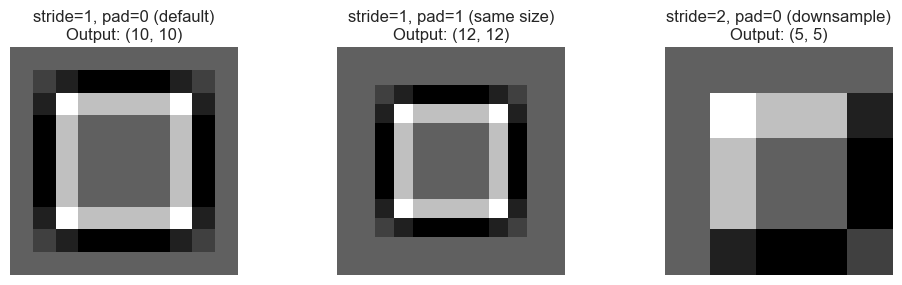

In [3]:
edge_kernel = kernels["edge"]

# Test three configurations
settings = [
    (1, 0, "stride=1, pad=0 (default)"),
    (1, 1, "stride=1, pad=1 (same size)"),
    (2, 0, "stride=2, pad=0 (downsample)"),
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (stride, padding, label) in zip(axes, settings):
    out = F.conv2d(toy, edge_kernel.unsqueeze(0), stride=stride, padding=padding)
    ax.imshow(out[0, 0].detach().numpy(), cmap="gray")
    ax.set_title(f"{label}\nOutput: {tuple(out.shape[-2:])}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Multi-Channel Convolution (RGB Images)

Real images have 3 color channels (RGB). How does convolution work here?

**Key concept**: A 3-channel input needs a 3-channel kernel (one per color). The convolution **sums over all channels** at each position.

- Input: H × W × 3 (height, width, RGB)
- Kernel: 3 × 3 × 3 (spatial 3×3, depth 3 for RGB)
- Output: H × W × 1 (single feature map)

For multiple output features, we use **multiple kernels** (each producing one feature map).

<div class="alert alert-block alert-info">
<b>QUESTION</b>

If we want to generate 64 feature maps from a 3-channel input using kernels with a 3x3 spatial size:
- How many kernels do we need? 
- What's the total number of weights? (Hint: don't forget the bias term for each kernel!)
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- We need 64 kernels, one for each feature map.
- Each kernel has 3×3×3 = 27 weights + 1 bias = 28 parameters. Total parameters = 64 kernels × 28 parameters/kernel = 1,792 parameters.
</div>

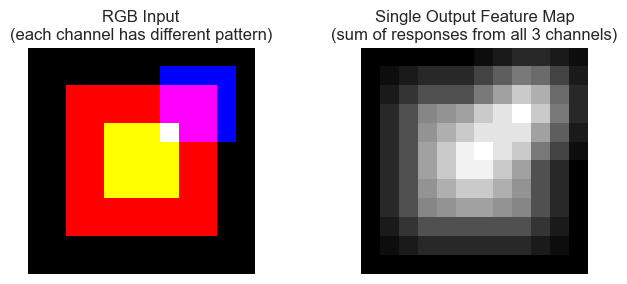

Multi-channel convolution:
Input shape: torch.Size([1, 3, 12, 12]) (batch, RGB, height, width)
Kernel shape: torch.Size([1, 3, 3, 3]) (out_ch, in_ch, kH, kW)
Output shape: torch.Size([1, 1, 12, 12]) (batch, 1 feature map, height, width)


In [4]:
# Create a toy RGB image with different patterns per channel
toy_rgb = torch.zeros(1, 3, 12, 12)
toy_rgb[:, 0, 2:10, 2:10] = 1.0  # Red channel: large square
toy_rgb[:, 1, 4:8, 4:8] = 1.0    # Green channel: small square
toy_rgb[:, 2, 1:5, 7:11] = 1.0   # Blue channel: offset square

# Simple 3-channel convolution (blur across all channels)
conv_rgb = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
with torch.no_grad():
    conv_rgb.weight[:] = 1.0 / 9.0  # Average all RGB values in 3×3 neighborhood

# Apply convolution to the RGB image
out_rgb = conv_rgb(toy_rgb)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Show RGB input
axes[0].imshow(toy_rgb[0].permute(1, 2, 0).numpy())
axes[0].set_title("RGB Input\n(each channel has different pattern)")
axes[0].axis("off")

# Show summed response
axes[1].imshow(out_rgb[0, 0].detach().numpy(), cmap="gray")
axes[1].set_title("Single Output Feature Map\n(sum of responses from all 3 channels)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Multi-channel convolution:")
print(f"Input shape: {toy_rgb.shape} (batch, RGB, height, width)")
print(f"Kernel shape: {conv_rgb.weight.shape} (out_ch, in_ch, kH, kW)")
print(f"Output shape: {out_rgb.shape} (batch, 1 feature map, height, width)")

## 1.3 Pooling: Downsampling for Efficiency

**Pooling** reduces spatial resolution while retaining important features. Benefits:
- Reduces computation in deeper layers
- Adds translation invariance (small shifts don't change pooled output)
- Reduces overfitting risk

### Common pooling operations:

1. **Max pooling**: Takes maximum value in each neighborhood
   - Preserves strongest activations
   - Most common in modern CNNs
   
2. **Average pooling**: Takes mean value in each neighborhood
   - Smoother but loses some detail

3. **Strided convolution**: Convolution with `stride > 1` can also downsample, but it mixes feature extraction and downsampling in one step.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Which operation will preserve more texture detail: max or average pooling?
- How is strided convolution similar to pooling? How is it different?
- What is the output size after applying 2×2 max pooling with stride 2 to a 12×12 feature map?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- Max pooling will preserve more texture detail because it retains the strongest activation in each region, while average pooling smooths out the activations and may lose important features.
- Strided convolution and pooling both halve the spatial dimensions.
</div>

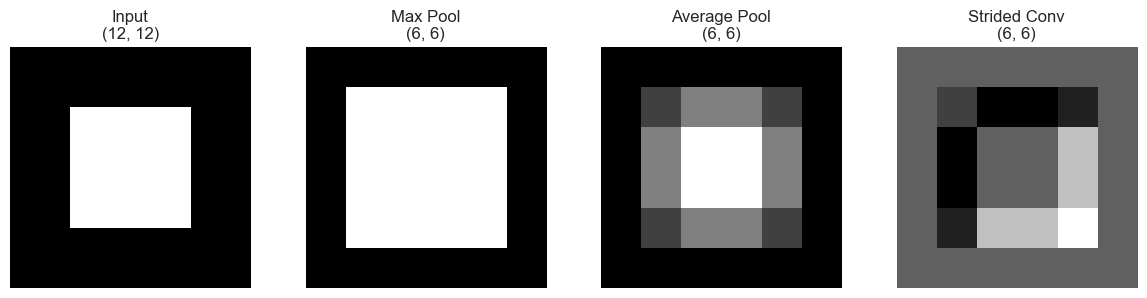

In [5]:
# Define three downsampling operations
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
stride_conv = nn.Conv2d(1, 1, kernel_size=3, stride=2, padding=1, bias=False)

# Use edge kernel for strided conv
with torch.no_grad():
    stride_conv.weight[:] = edge_kernel

# Apply all three
max_out = max_pool(toy)
avg_out = avg_pool(toy)
stride_out = stride_conv(toy)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].imshow(toy[0, 0].numpy(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Input\n{tuple(toy.shape[-2:])}")
axes[0].axis("off")

axes[1].imshow(max_out[0, 0].detach().numpy(), cmap="gray")
axes[1].set_title(f"Max Pool\n{tuple(max_out.shape[-2:])}")
axes[1].axis("off")

axes[2].imshow(avg_out[0, 0].detach().numpy(), cmap="gray")
axes[2].set_title(f"Average Pool\n{tuple(avg_out.shape[-2:])}")
axes[2].axis("off")

axes[3].imshow(stride_out[0, 0].detach().numpy(), cmap="gray")
axes[3].set_title(f"Strided Conv\n{tuple(stride_out.shape[-2:])}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

---
## Part 2: Building a Real CNN on CIFAR-10

Now that you understand the building blocks, let's build a real CNN! We'll use **CIFAR-10**, a classic computer vision dataset with 60,000 tiny 32×32 color images in 10 classes. The CIFAR-10 dataset contains 32×32 RGB images of airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. It is a widely used benchmark for image classification tasks.

In [6]:
# CIFAR-10 class names
cifar10_labels = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

# Standard normalization for CIFAR-10 (computed from training set)
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to tensor [0, 1]
    transforms.Normalize(mean, std),  # Normalize to mean=0, std=1
])

# Load CIFAR-10 datasets
train_data = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=train_transform)

print(f"Successfully loaded CIFAR-10 dataset!")
print(f"- Training samples: {len(train_data)}")
print(f"- Test samples: {len(test_data)}")

/Users/jolan.heyse/Library/CloudStorage/OneDrive-VIB/Documents/Course Material/2026/machine-learning-and-deep-learning-fundamentals/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Successfully loaded CIFAR-10 dataset!
- Training samples: 50000
- Test samples: 10000


## 2.1 Visualize Sample Images

Let's peek at some training images to get a feel for the data. Notice how small 32×32 images are - yet CNNs can learn to classify them accurately!

<div class="alert alert-block alert-info">
<b>OBSERVATION QUESTIONS</b>

- Can you recognize objects in these tiny images?
- Are some classes harder to distinguish than others (e.g., cat vs dog)?
- How might data quality affect model performance?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- Due to the low resolution, it can be challenging to recognize objects, especially for classes with similar features (e.g., cats vs dogs).
- Some classes may be harder to distinguish due to similar visual features, such as cats and dogs, or airplanes and ships.
- Data quality can significantly affect model performance. If the images are blurry, have poor lighting, or contain noise, the model may struggle to learn meaningful features, leading to lower accuracy.
</div>

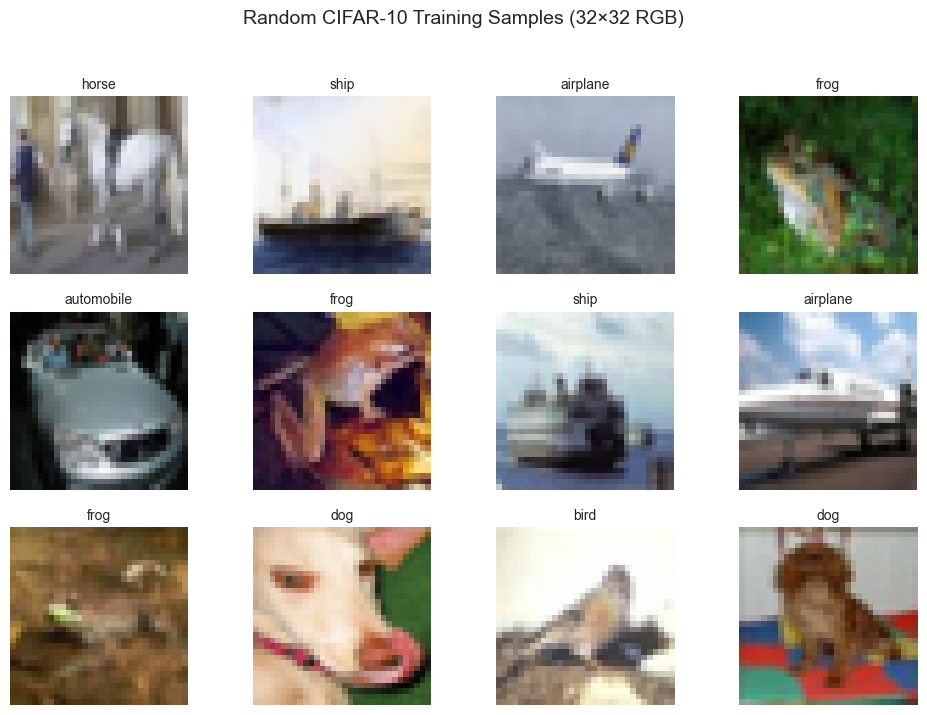

In [7]:
def denormalize(tensor, mean, std):
    """Reverse normalization for visualization"""
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return tensor * std_t + mean_t

def show_batch(dataset, labels, n=12):
    """Display a grid of random samples"""
    indices = np.random.choice(len(dataset), size=n, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(10, 7))
    
    for ax, idx in zip(axes.flatten(), indices):
        image, label = dataset[idx]
        if isinstance(image, torch.Tensor):
            image = denormalize(image, mean, std).clamp(0, 1)
            image = image.permute(1, 2, 0).numpy()
        ax.imshow(image)
        ax.set_title(labels[int(label)], fontsize=10)
        ax.axis("off")
    
    plt.suptitle("Random CIFAR-10 Training Samples (32×32 RGB)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

show_batch(train_data, cifar10_labels)

## 2.2 Prepare Data Loaders

We create train/validation splits and DataLoaders for efficient mini-batch training.

**Why validation set?**
- Monitor overfitting during training
- Select best model (best val accuracy)
- Never touch test set until final evaluation!

**Mini-batch benefits:**
- Memory efficient (don't load entire dataset at once)
- Faster convergence (more frequent weight updates)
- Better generalization (noise in gradients acts as regularization)

In [8]:
# Create validation split from training data
val_size = 5000
train_size = len(train_data) - val_size

batch_size = 128

train_ds, val_ds = random_split(
    train_data  ,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("Data loaders ready:")
print(f"- Train: {len(train_ds)} samples ({len(train_loader)} batches)")
print(f"- Validation: {len(val_ds)} samples ({len(val_loader)} batches)")
print(f"- Test: {len(test_data)} samples ({len(test_loader)} batches)")
print(f"- Batch size: {batch_size}")

Data loaders ready:
- Train: 45000 samples (352 batches)
- Validation: 5000 samples (40 batches)
- Test: 10000 samples (79 batches)
- Batch size: 128


## 2.3 Define a Compact CNN Architecture

Time to build our CNN! We'll use a simple but effective architecture:

### Architecture Overview:
```
Input: 32×32×3 (RGB image)
  ↓
[Conv 32 filters (3×3) + BatchNorm + ReLU + MaxPool] → 16×16×32
  ↓
[Conv 64 filters (3×3) + BatchNorm + ReLU + MaxPool] → 8×8×64
  ↓
[Conv 128 filters (3×3) + BatchNorm + ReLU + MaxPool] → 4×4×128
  ↓
Flatten → 2048 features
  ↓
[Dense 128 + ReLU + Dropout(0.3)] → 128 features
  ↓
[Dense 10] → 10 class scores
  ↓
Output: Class probabilities (via softmax in loss)
```

### Design choices:
- **3 conv blocks**: Gradually increase filters (32→64→128)
- **BatchNorm**: Stabilizes training
- **MaxPool**: Reduces spatial dimensions (32→16→8→4)
- **Small kernels (3×3)**: Efficient and effective

<div class="alert alert-block alert-info">
<b>ARCHITECTURE QUESTIONS</b>

- Why do we increase the number of filters (32→64→128) as we go deeper?
- Why don't we use dropout in the convolutional layers?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- We increase the number of filters as we go deeper because deeper layers capture more complex and abstract features. As the spatial dimensions decrease due to pooling, we can afford to have more filters to capture a richer set of features without increasing computational cost too much.
- Dropout is typically not used in convolutional layers because it can disrupt the spatial structure of the features. Convolutional layers rely on local patterns, and randomly dropping activations can lead to loss of important spatial information.
</div>

In [16]:
class SmallCNN(nn.Module):
    """Compact CNN for CIFAR-10 classification"""
    def __init__(self, num_classes=10):
        super().__init__()
        
        # Feature extraction: 3 convolutional blocks
        self.features = nn.Sequential(
            # Block 1: 32×32×3 → 16×16×32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 2: 16×16×32 → 8×8×64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            # Block 3: 8×8×64 → 4×4×128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),  # 4×4×128 = 2048 features
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Initialize model
model = SmallCNN(num_classes=10).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nModel Statistics:")
print(f"- Total parameters: {total_params:,}")
print(f"- Trainable parameters: {trainable_params:,}")
print(f"\nCompare to fully-connected: 32×32×3 × 128 = {32*32*3*128:,} parameters (just first layer!)")

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(

## 2.4 Train the CNN

Time to train! We'll use:
- **Cross-entropy loss**: Standard for classification
- **Adam optimizer**: Adaptive learning rates
- **Learning rate 1e-3**: Good default for Adam

We keep epochs modest (~10) so training completes quickly while still showing clear learning.

In [17]:
def accuracy_from_logits(logits, targets):
    preds = torch.argmax(logits, dim=1)
    return (preds == targets).float().mean().item()


def evaluate_loader(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_items = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Forward pass
            logits = model(inputs)

            # Compute loss and accuracy
            loss = criterion(logits, targets)

            batch_size = inputs.size(0)
            total_loss += loss.item() * batch_size
            total_acc += accuracy_from_logits(logits, targets) * batch_size
            total_items += batch_size

    return total_loss / total_items, total_acc / total_items


def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_acc = 0.0
        total_items = 0

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Forward pass
            optimizer.zero_grad()
            logits = model(inputs)

            # Compute loss
            loss = criterion(logits, targets)

            # Backward pass and update model weights
            loss.backward()
            optimizer.step()

            batch_size = inputs.size(0)
            running_loss += loss.item() * batch_size
            running_acc += accuracy_from_logits(logits, targets) * batch_size
            total_items += batch_size

        train_loss = running_loss / total_items
        train_acc = running_acc / total_items
        val_loss, val_acc = evaluate_loader(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d} | train loss {train_loss:.3f} acc {train_acc:.3f} | val loss {val_loss:.3f} acc {val_acc:.3f}")

    return history

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

# Train the model and collect history
history = fit(model, train_loader, val_loader, criterion, optimizer, device, epochs)

Epoch 01 | train loss 1.237 acc 0.555 | val loss 1.081 acc 0.623
Epoch 02 | train loss 0.851 acc 0.701 | val loss 0.945 acc 0.679
Epoch 03 | train loss 0.715 acc 0.750 | val loss 0.867 acc 0.698
Epoch 04 | train loss 0.620 acc 0.783 | val loss 0.726 acc 0.745
Epoch 05 | train loss 0.545 acc 0.811 | val loss 0.871 acc 0.706
Epoch 06 | train loss 0.479 acc 0.835 | val loss 0.710 acc 0.758
Epoch 07 | train loss 0.409 acc 0.858 | val loss 0.708 acc 0.770
Epoch 08 | train loss 0.359 acc 0.875 | val loss 0.721 acc 0.763
Epoch 09 | train loss 0.301 acc 0.896 | val loss 0.768 acc 0.764
Epoch 10 | train loss 0.264 acc 0.907 | val loss 0.814 acc 0.756


## 2.5 Visualize Training Curves

Learning curves tell the story of training. Let's see how our CNN learned!

Even with a simple architecture and small number of epochs, the model already reaches more than 70% validation accuracy! This shows the power of CNNs even on small datasets.

<div class="alert alert-block alert-info">
<b>INTERPRETATION QUESTIONS</b>

- At what epoch did the model converge (stop improving significantly)?
- Is there evidence of overfitting (train >> val)?
- Would training for more epochs help or hurt?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- The model did not fully converge within 10 epochs, as the validation accuracy is still improving.
- There is no strong evidence of overfitting yet, as the validation accuracy is still increasing and not diverging from the training accuracy.
- Training for more epochs would likely help improve validation accuracy further.
</div>

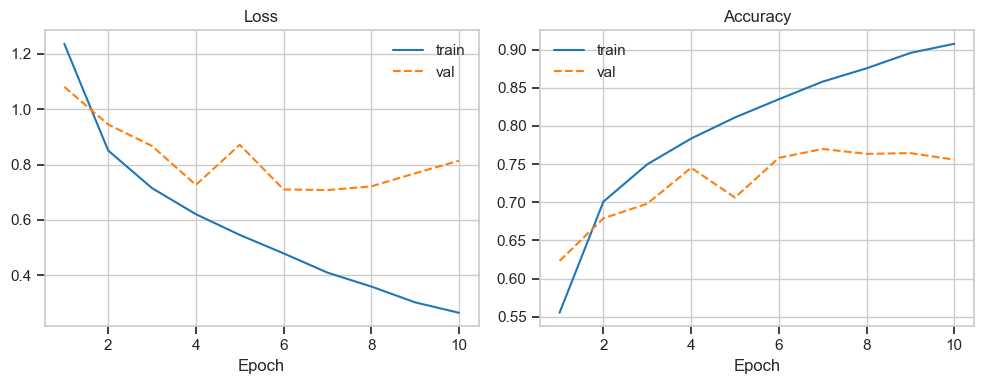

In [18]:
epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs_axis, history["train_loss"], label="train")
axes[0].plot(epochs_axis, history["val_loss"], label="val", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_axis, history["train_acc"], label="train")
axes[1].plot(epochs_axis, history["val_acc"], label="val", linestyle="--")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2.6 Evaluate on the test set

<div class="alert alert-block alert-info">
<b> QUESTIONS </b>

- What is the final test accuracy? Is it good for this dataset?
- Are mistakes semantically reasonable (cat↔dog) or random?
- Are some classes much harder than others?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- The final test accuracy is around 70%, which is a good result for a simple CNN on CIFAR-10. With more complex architectures and data augmentation, we can achieve even higher accuracy.
- Mistakes are often semantically reasonable, such as confusing cats and dogs, or airplanes and ships, due to similar visual features.
- Some classes may be harder than others, especially those with similar features or less distinctive characteristics.
</div>

Test loss: 0.845 | Test accuracy: 0.761


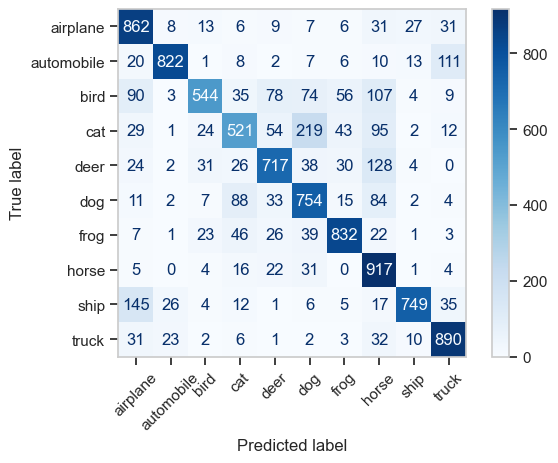

In [19]:
test_loss, test_acc = evaluate_loader(model, test_loader, criterion, device)
print(f"Test loss: {test_loss:.3f} | Test accuracy: {test_acc:.3f}")

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        logits = model(inputs)
        preds = torch.argmax(logits, dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(targets)

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

disp = ConfusionMatrixDisplay.from_predictions(
    all_targets.numpy(),
    all_preds.numpy(),
    display_labels=cifar10_labels,
    xticks_rotation=45,
    cmap="Blues",
)
plt.grid(False)
plt.tight_layout()

## 2.7 Test Set Predictions

Let's see our CNN in action on individual test images!

This is the most honest evaluation - these images were never seen during training or validation.

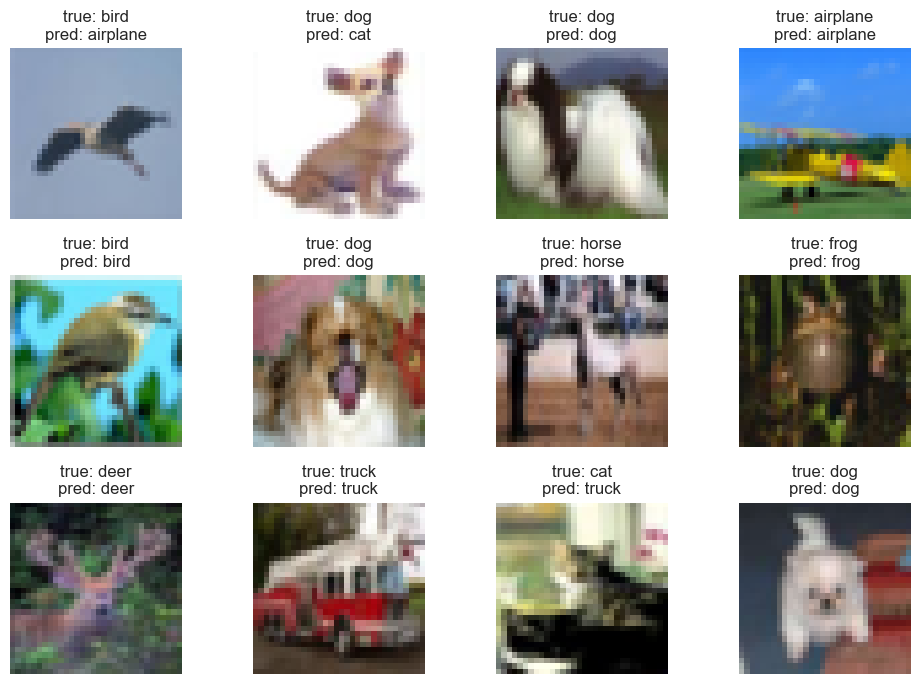

In [20]:
def show_predictions(dataset, model, labels, n=12):
    indices = np.random.choice(len(dataset), size=n, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(10, 7))

    model.eval()
    with torch.no_grad():
        for ax, idx in zip(axes.flatten(), indices):
            image, label = dataset[idx]
            input_tensor = image.unsqueeze(0).to(device)
            logits = model(input_tensor)
            pred = torch.argmax(logits, dim=1).item()

            img = denormalize(image, mean, std).clamp(0, 1).permute(1, 2, 0).numpy()
            ax.imshow(img)
            ax.set_title(f"true: {labels[int(label)]}\npred: {labels[int(pred)]}")
            ax.axis("off")

    plt.tight_layout()

show_predictions(test_data, model, cifar10_labels)

## Summary and Key Takeaways

Congratulations! You've mastered CNN fundamentals. Here's what we learned:

### Core Concepts:
- **Convolution**: Local pattern detection with weight sharing
- **Padding/Stride**: Control output dimensions
- **Pooling**: Downsampling for efficiency and invariance
- **Hierarchical features**: Low-level → mid-level → high-level

### Why CNNs Work for Images:
- **Parameter efficiency**: Millions fewer parameters than fully-connected
- **Translation invariance**: Detect features anywhere in image
- **Hierarchical learning**: Automatically learn feature hierarchy
- **Scalability**: Work for any image size

### Architecture Principles:
- Start with small feature maps, increase depth
- Use 3×3 kernels (efficient and effective)
- BatchNorm + Dropout for regularization
- MaxPool for downsampling

---
## Optional Exercises (for early finishers)

## Part 3: Visualizing What the CNN Learned

This is where it gets really interesting! We'll peek inside the trained CNN to see:
1. **Learned filters**: What patterns did the first layer learn to detect?
2. **Feature maps**: How does an image activate different filters?

This visualization helps us understand WHY the CNN works!

### 3.1 Visualize Learned Filters

The first convolutional layer learns basic feature detectors. Let's see what our CNN learned!

We can visualize the 32 filters in the first layer as 3×3 RGB images. Each filter will show us what pattern it responds to:
- Edge detectors will show strong contrasts
- Color detectors will show specific color patterns
- Texture detectors will show more complex patterns

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Can you identify any edge detectors among the filters?
- Do you find that these filters help to explain how the CNN processes images?
- What does this tell you about the interpretability of CNNs?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- Some filters show strong contrasts, indicating they are edge detectors. Others may show specific color patterns, suggesting they are color detectors.
- In practice, the 3x3 filters are often too small to be easily interpretable by humans, but they do capture important low-level features that are crucial for the CNN's performance.
- This tells us that while CNNs can learn meaningful features, the interpretability of these features can be limited.
</div>

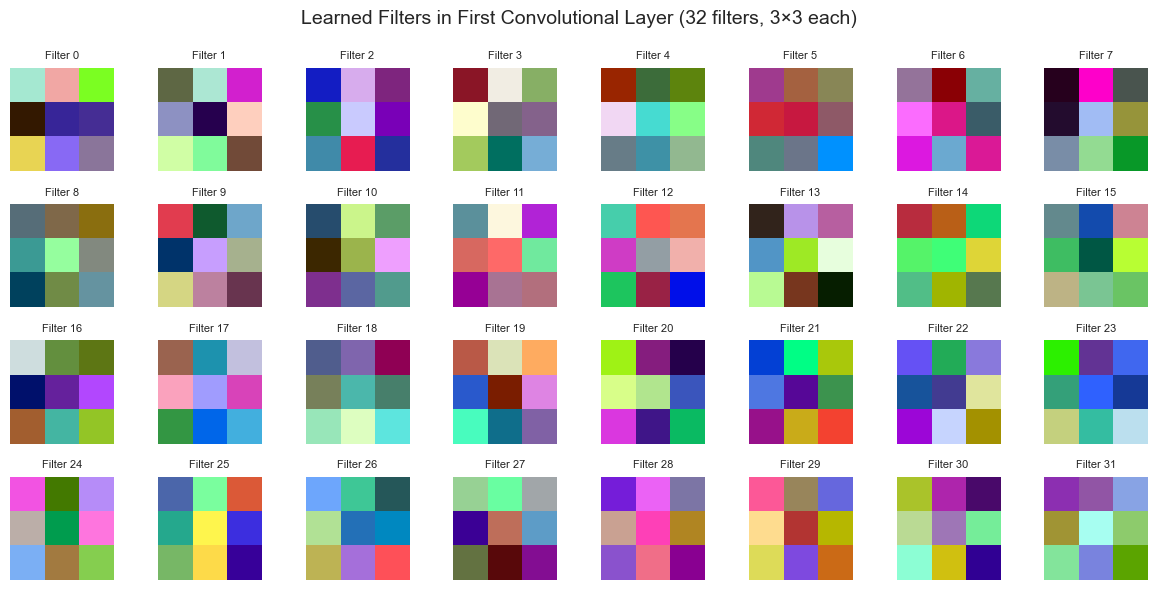

In [21]:
# Extract first convolutional layer
first_layer = model.features[0]
weights = first_layer.weight.detach().cpu()  # Shape: [32, 3, 3, 3]
num_filters = weights.shape[0]

# Visualize all 32 learned filters
cols = 8
rows = int(np.ceil(num_filters / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(rows * cols):
    ax = axes.flatten()[i]
    if i < num_filters:
        w = weights[i]  # Shape: [3, 3, 3] (RGB, 3×3 spatial)
        # Normalize to [0, 1] for visualization
        w = (w - w.min()) / (w.max() - w.min() + 1e-6)
        ax.imshow(w.permute(1, 2, 0))  # Convert to HWC for matplotlib
        ax.set_title(f"Filter {i}", fontsize=8)
    ax.axis("off")

plt.suptitle("Learned Filters in First Convolutional Layer (32 filters, 3×3 each)", fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Visualize Feature Maps

Feature maps show how a real image **activates** these filters. We can compute the feature maps by passing an image through the convolutional layer. Each filter produces one feature map showing where it detected its pattern.

We'll:
1. Take one test image
2. Pass it through the feature extractor
3. Visualize the resulting feature maps

**Interpretation**: Bright regions in a feature map = strong activation = filter detected its pattern there!

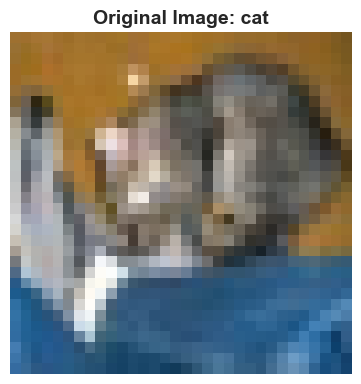

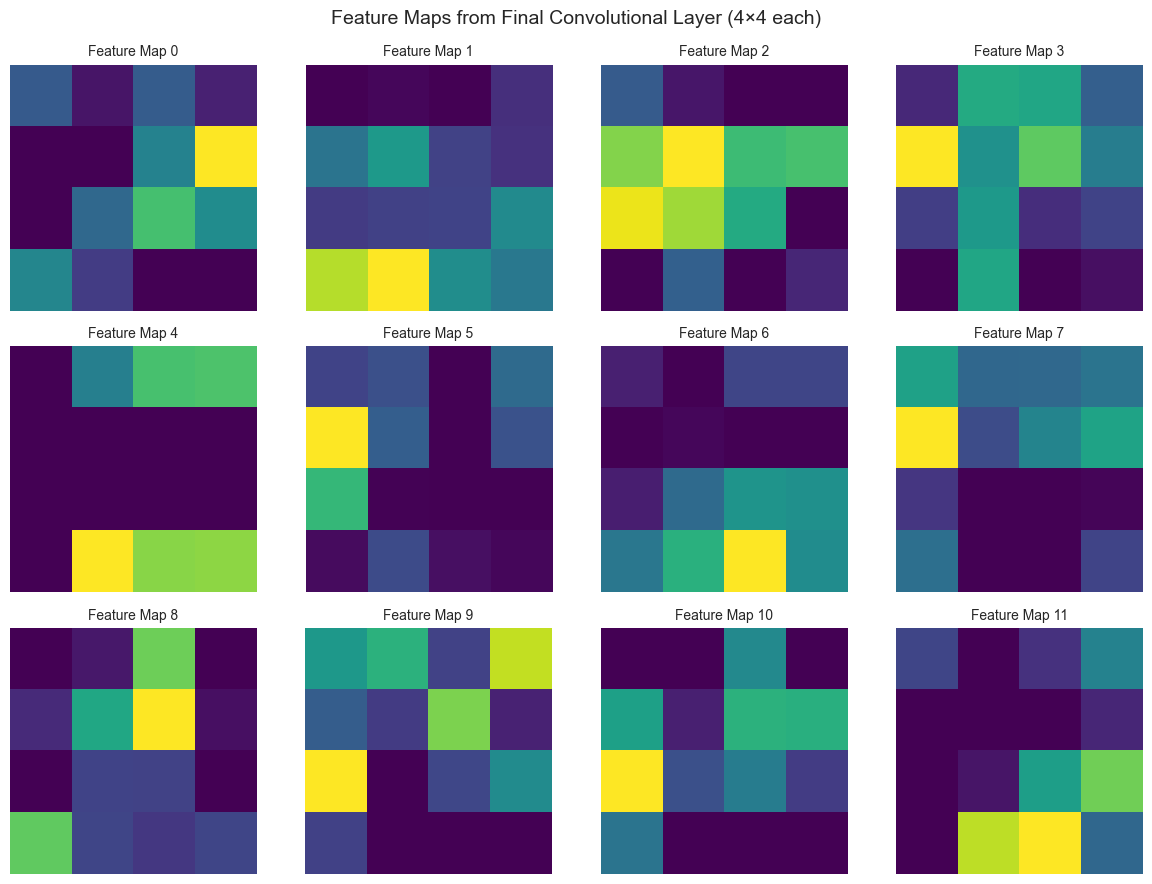

In [22]:
# Get one test image
sample_image, sample_label = test_data[0]

# Pass through feature extractor only (not classifier)
model.eval()
with torch.no_grad():
    fmap = model.features(sample_image.unsqueeze(0).to(device)).cpu()[0]
    # fmap shape: [128, 4, 4] (128 feature maps, each 4×4)

# Show original image
img_vis = denormalize(sample_image, mean, std).clamp(0, 1).permute(1, 2, 0).numpy()
plt.figure(figsize=(4, 4))
plt.imshow(img_vis)
plt.title(f"Original Image: {cifar10_labels[int(sample_label)]}", fontsize=14, fontweight='bold')
plt.axis("off")
plt.tight_layout()
plt.show()

# Show first 12 feature maps from final conv layer
num_maps = min(12, fmap.shape[0])
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i, ax in enumerate(axes.flatten()):
    if i < num_maps:
        ax.imshow(fmap[i].detach().numpy(), cmap="viridis")
        ax.set_title(f"Feature Map {i}", fontsize=10)
    ax.axis("off")

plt.suptitle("Feature Maps from Final Convolutional Layer (4×4 each)", fontsize=14)
plt.tight_layout()
plt.show()

### 3.3 Create a saliency map

Saliency maps are used to highlight which parts of the input most influenced the model's prediction. The core idea is to measure how sensitive the predicted class score is to changes in each input pixel. If changing a pixel causes a big change in the predicted class score, that pixel is important for the model's decision. If changing a pixel has little effect on the predicted class score, that pixel is less important.

The simplest way to compute a saliency map is to take the **gradient of the predicted class score with respect to the input pixels**. This tells us how much each pixel influenced the prediction. This involves:
- Forward pass to get predicted class score
- Backward pass to compute gradients (the gradients are computed for each layer, but we focus on the input gradients)
- Saliency map: take absolute value of gradients and take the maximum across color channels

Saliency maps don't show us how the model processes features, but they show us WHERE the model is looking in the image.

<div class="alert alert-block alert-info">
<b>QUESTIONS</b>

- Where are the most salient regions for the predicted class?
- Do these regions correspond to the object in the image?
</div>

<div class="alert alert-block alert-warning">
<b>ANSWERS</b>

- The saliency map highlights regions on and around the cat, which gives us confidence that the model is focusing on the relevant parts of the image for its prediction.
- Yes, the salient regions correspond to the object in the image (the cat).
</div>

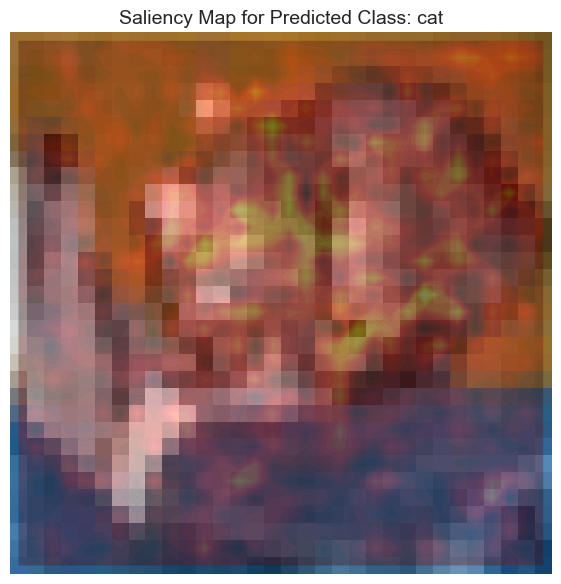

In [23]:
# Plot the saliency map for the predicted class as an overlay on the original image
model.eval()
input_tensor = sample_image.unsqueeze(0).to(device).requires_grad_(True)

# Forward pass and prediction
logits = model(input_tensor)
pred_class = torch.argmax(logits, dim=1).item()

# Backward pass to compute gradients
logits[0, pred_class].backward()

# Saliency map: take absolute value of gradients and max across color channels
saliency = input_tensor.grad.abs().squeeze().cpu()  # Shape: [3, 32, 32]
saliency, _ = saliency.max(dim=0)  # Take max across color channels

# Plot original image with saliency map overlay
plt.figure(figsize=(6, 6))
plt.imshow(img_vis)
cnt = plt.contourf(saliency.numpy(), levels=20, cmap="hot", alpha=0.3, antialiased=True)  # Contour overlay
plt.title(f"Saliency Map for Predicted Class: {cifar10_labels[pred_class]}", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()